# S3.2 — Metric Ablation

Joint max-Z test with **p-value** detection:

$$T_{\text{obs}} = \max(Z_{\text{obs,dcor}},\; Z_{\text{obs,MIC}},\; \ldots)$$

$$p = \frac{\sum_{j=1}^{N_{\text{null}}} \mathbf{1}(T_{\text{null},j} \ge T_{\text{obs}}) + 1}{N_{\text{null}} + 1}$$

$$p \le \alpha \;\Rightarrow\; \text{reject } H_0 \;\Rightarrow\; \text{detectable relationship}$$

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3,
})

S1_DIR = Path('output/S1')
S3_DIR = Path('output/S3')
OUT_DIR = Path('output/S3.2')
OUT_DIR.mkdir(parents=True, exist_ok=True)

ALPHA = 0.05

# ── Configuration toggles ──
USE_SPLIT         = True
TRAIN_FRACTION    = 0.5
RANDOM_SEED       = 20260623

# ── Metric filter toggles (shared with S3.0, S3.3) ──
EXCLUDE_REVERSED = True   # 8 bw metrics: z↑ = no relationship, wrong for max-Z
EXCLUDE_WEAK     = True   # 9 metrics with signal/null separation < 0.5
EXCLUDE_RAW      = True   # 12 scale-dependent unbounded metrics
MERGE_DCOR_DCOV  = True   # remove dcov (mathematically redundant with dcor)

# Category weights for weighted macro power
CATEGORY_WEIGHTS = {'mean_only': 2, 'variance_only': 1, 'mean+variance': 2}

## §1 Load data & categories

In [2]:
df = pd.read_parquet(S3_DIR / 'permutation_all.parquet')
Z_COLS = sorted([c for c in df.columns if c.startswith('z_')])

cases_main = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
cases_null = pd.read_csv(S1_DIR / 'null_expanded_cases.csv', low_memory=False)
cases_null['case_id'] = cases_null['case_id'] + cases_main['case_id'].max()

meta_cols = ['case_id', 'family_id', 'snr', 'spread_pattern', 'x_distribution']
cases_all = pd.concat([cases_main[meta_cols], cases_null[meta_cols]], ignore_index=True)
df = df.merge(cases_all, on='case_id', how='left')

is_null = df['family_id'] == 'Null'
is_const = df['spread_pattern'] == 'constant'
df['category'] = 'mean+variance'
df.loc[is_null & is_const, 'category'] = 'true_null'
df.loc[is_null & ~is_const, 'category'] = 'variance_only'
df.loc[~is_null & is_const, 'category'] = 'mean_only'

print(f'Total: {len(df):,}')
print(df['category'].value_counts().to_string())

Total: 15,008
category
true_null        4032
mean_only        4000
mean+variance    4000
variance_only    2976


## §2 MINE-covered subset

In [3]:
MINE_COLS = [c for c in Z_COLS if any(c == f'z_{m}' for m in ['mic','mas','mev','mcn','mic_minus_r2','lowess_r2'])]
mine_covered = df[MINE_COLS].notna().all(axis=1)
df = df[mine_covered].copy()
Z_COLS = sorted([c for c in Z_COLS if df[c].notna().all()])
print(f'MINE-covered: {len(df):,}')
print(f'Z-score columns with full coverage: {len(Z_COLS)}')

MINE-covered: 15,008
Z-score columns with full coverage: 45


## §3 Metric groups & exclusions

In [ ]:
METRIC_GROUPS = {}
METRIC_DISPLAY = {}

GROUP_DEFS = {
    'correlation': ['z_abs_pearson_r', 'z_abs_spearman_rho', 'z_abs_covariance'],
    'distance':    ['z_dcor', 'z_dcov'],
    'mine':        ['z_mic', 'z_mas', 'z_mev', 'z_mcn', 'z_mic_minus_r2'],
    'bin':         [c for c in Z_COLS if 'bin' in c],
    'distribution':['z_ec_dist_ks', 'z_ec_dist_wass', 'z_ew_dist_ks', 'z_ew_dist_wass'],
    'nonlinear':   ['z_lowess_r2'],
    'slope':       [c for c in Z_COLS if 'ep_' in c or 'pf_' in c or 'seg_' in c],
}
for g, cols in GROUP_DEFS.items():
    for c in cols:
        if c in Z_COLS:
            METRIC_GROUPS[c] = g

NICE = {
    'z_abs_pearson_r': '|Pearson|', 'z_abs_spearman_rho': '|Spearman|',
    'z_abs_covariance': 'Covariance',
    'z_dcor': 'dcor', 'z_dcov': 'dcov',
    'z_mic': 'MIC', 'z_mas': 'MAS', 'z_mev': 'MEV', 'z_mcn': 'MCN',
    'z_mic_minus_r2': 'MIC−r²',
    'z_ec_bin_eta2': 'η²(EC)', 'z_ew_bin_eta2': 'η²(EW)',
    'z_ec_dist_ks': 'KS(EC)', 'z_ec_dist_wass': 'Wass(EC)',
    'z_ew_dist_ks': 'KS(EW)', 'z_ew_dist_wass': 'Wass(EW)',
    'z_lowess_r2': 'LOWESS R²',
}
for c in Z_COLS:
    METRIC_DISPLAY[c] = NICE.get(c, c.replace('z_', ''))

# ── Apply metric filter toggles ──
_reversed = {c for c in Z_COLS if '_bin_bw_' in c}
_weak = {c for c in Z_COLS
         if any(c.endswith(s) for s in ['_ep_early', '_ep_mid', '_ep_late'])
         or c in ('z_raw_seg_strength', 'z_std_seg_strength', 'z_mcn')}
_raw = {c for c in Z_COLS
        if c.startswith('z_abs_raw_') or c == 'z_raw_seg_strength'
        or c == 'z_abs_covariance' or '_bin_amp' in c}

exclude = set()
if EXCLUDE_REVERSED: exclude |= _reversed
if EXCLUDE_WEAK:     exclude |= _weak
if EXCLUDE_RAW:      exclude |= _raw
if MERGE_DCOR_DCOV and 'z_dcov' in Z_COLS:
    exclude.add('z_dcov')

SAFE_METRICS = [c for c in Z_COLS if c in METRIC_GROUPS and c not in exclude]

print(f'Metric filtering: {len(Z_COLS)} total → {len(SAFE_METRICS)} safe '
      f'(excluded {len(exclude)}: '
      f'reversed={len(_reversed & exclude)}, weak={len(_weak & exclude)}, '
      f'raw={len(_raw & exclude)}, dcov={1 if "z_dcov" in exclude else 0})')

print(f'\nFinal: {len(SAFE_METRICS)} metrics')
for m in SAFE_METRICS:
    print(f'  {METRIC_DISPLAY[m]:15s}  ({METRIC_GROUPS[m]})')

## §4 Train / Validation split

In [5]:
if USE_SPLIT:
    rng = np.random.default_rng(RANDOM_SEED)
    df['split'] = 'validation'
    for _, idx in df.groupby(['category', 'x_distribution'], dropna=False).groups.items():
        idx = np.array(list(idx)).copy()
        rng.shuffle(idx)
        n_train = max(1, min(int(round(len(idx) * TRAIN_FRACTION)), len(idx) - 1))
        df.loc[idx[:n_train], 'split'] = 'train'
    train = df[df['split'] == 'train'].copy()
    validation = df[df['split'] == 'validation'].copy()
    print(df.groupby(['split', 'category']).size().unstack(fill_value=0))
else:
    df['split'] = 'all'
    train = df.copy()
    validation = df.copy()
    print(f'USE_SPLIT=False → all {len(df):,} cases')

POWER_LABEL = 'Validation Power' if USE_SPLIT else 'Power'

category    mean+variance  mean_only  true_null  variance_only
split                                                         
train                2001       2001       2016           1488
validation           1999       1999       2016           1488


## §4.5 Calibration screen

Remove metrics that behave pathologically under the null (same filter as S3.4).

In [6]:
train_null = train[train['category'] == 'true_null']
calib_rows = []
for zc in SAFE_METRICS:
    z_null = train_null[zc].dropna()
    calib_rows.append({
        'metric': zc,
        'display': METRIC_DISPLAY[zc],
        'group': METRIC_GROUPS[zc],
        'n_valid': int(len(z_null)),
        'mean_null': float(z_null.mean()) if len(z_null) else np.nan,
        'std_null': float(z_null.std()) if len(z_null) > 1 else np.nan,
    })

calib = pd.DataFrame(calib_rows)
calib['flag_bias']   = calib['mean_null'].abs() > 1.0
calib['flag_degen']  = calib['std_null'] < 0.3
calib['flag_unstable'] = calib['std_null'] > 3.0

flagged = calib[calib[['flag_bias','flag_degen','flag_unstable']].any(axis=1)]
SAFE_METRICS = calib.loc[~calib[['flag_bias','flag_degen','flag_unstable']].any(axis=1), 'metric'].tolist()

print(f'After calibration screen: {len(SAFE_METRICS)} metrics')
if len(flagged):
    print(f'Removed {len(flagged)} flagged metrics:')
    print(flagged[['display','group','mean_null','std_null','flag_bias','flag_degen','flag_unstable']].to_string(index=False))


After calibration screen: 43 metrics


## §5 Evaluation functions (max-Z + p-value)

For metric set $S$ and case $i$:

$$T_i = \max_{m \in S}(Z_{i,m})$$
$$p_i = \frac{\sum_{j \in \text{null}} \mathbf{1}(T_j \ge T_i) + 1}{N_{\text{null}} + 1}$$

Detect if $p_i \le \alpha$.

In [7]:
def compute_null_T(data, z_metrics):
    """Get the null distribution of T = max(Z) for calibration."""
    null_data = data[data['category'] == 'true_null']
    T_null = null_data[z_metrics].max(axis=1).dropna()
    return np.sort(T_null.values)

def compute_pvalues(T_obs, null_T_sorted):
    """p = (#null T >= T_obs + 1) / (N_null + 1), with +1 correction."""
    n = len(null_T_sorted)
    ranks = np.searchsorted(null_T_sorted, T_obs.values, side='left')
    return pd.Series((n - ranks + 1) / (n + 1), index=T_obs.index)

def evaluate_combo(z_metrics, data_fit, data_eval, alpha=ALPHA):
    z_metrics = list(z_metrics)
    null_T = compute_null_T(data_fit, z_metrics)
    T_eval = data_eval[z_metrics].max(axis=1)
    p_eval = compute_pvalues(T_eval, null_T)
    detected = p_eval <= alpha

    out = {'n_metrics': len(z_metrics)}
    for cat in ['true_null', 'mean_only', 'variance_only', 'mean+variance']:
        mask = data_eval['category'] == cat
        out[f'n_{cat}'] = int(mask.sum())
        out[f'rate_{cat}'] = float(detected[mask].mean()) if mask.sum() else np.nan

    signal = data_eval['category'] != 'true_null'
    out['overall_power'] = float(detected[signal].mean()) if signal.sum() else np.nan
    return out

def make_row(z_metrics, label=None, kind=None):
    z_metrics = list(z_metrics)
    train_result = evaluate_combo(z_metrics, train, train)
    val_result = evaluate_combo(z_metrics, train, validation)
    
    mo = val_result['rate_mean_only']
    vo = val_result['rate_variance_only']
    mv = val_result['rate_mean+variance']
    _w = CATEGORY_WEIGHTS
    _pairs = [(mo, _w['mean_only']), (vo, _w['variance_only']), (mv, _w['mean+variance'])]
    _valid = [(r, wt) for r, wt in _pairs if r is not None and not np.isnan(r)]
    
    # Train macro power
    t_mo = train_result['rate_mean_only']
    t_vo = train_result['rate_variance_only']
    t_mv = train_result['rate_mean+variance']
    _t_pairs = [(t_mo, _w['mean_only']), (t_vo, _w['variance_only']), (t_mv, _w['mean+variance'])]
    _t_valid = [(r, wt) for r, wt in _t_pairs if r is not None and not np.isnan(r)]
    
    return {
        'label': label or ', '.join(METRIC_DISPLAY[m] for m in z_metrics),
        'kind': kind or 'combo',
        'k': len(z_metrics),
        'metrics': ','.join(z_metrics),
        'display_metrics': ', '.join(METRIC_DISPLAY[m] for m in z_metrics),
        'validation_overall_power': val_result['overall_power'],
        'validation_macro_power': float(sum(r*wt for r,wt in _valid) / sum(wt for _,wt in _valid)) if _valid else np.nan,
        'validation_FPR': val_result['rate_true_null'],
        'validation_MO': mo, 'validation_VO': vo, 'validation_MV': mv,
        'train_overall_power': train_result['overall_power'],
        'train_macro_power': float(sum(r*wt for r,wt in _t_valid) / sum(wt for _,wt in _t_valid)) if _t_valid else np.nan,
        'train_FPR': train_result['rate_true_null'],
    }

print('Evaluation ready: T = max(Z), p = (#null≥T+1)/(N+1), reject if p ≤ α')

Evaluation ready: T = max(Z), p = (#null≥T+1)/(N+1), reject if p ≤ α


## §6 Baseline

In [8]:
baseline = make_row(SAFE_METRICS, label='all_safe', kind='baseline')
FULL_POWER = baseline['validation_macro_power']
print(f'All {len(SAFE_METRICS)} metrics:')
print(f'  Power = {FULL_POWER:.4f}')
print(f'  FPR   = {baseline["validation_FPR"]:.4f}')

All 43 metrics:
  Power = 0.9785
  FPR   = 0.0476


## §7 Individual metric power

In [9]:
individual_rows = []
for m in SAFE_METRICS:
    row = make_row([m], label=METRIC_DISPLAY[m], kind='individual')
    row['group'] = METRIC_GROUPS[m]
    individual_rows.append(row)

individual = pd.DataFrame(individual_rows).sort_values('train_macro_power', ascending=False)
individual.to_csv(OUT_DIR / 'individual_metrics.csv', index=False, float_format='%.6f')

cols = ['label', 'group', 'validation_macro_power', 'validation_FPR',
        'validation_MO', 'validation_VO', 'validation_MV']
print(individual[cols].to_string(index=False, float_format='{:.3f}'.format))

             label        group  validation_macro_power  validation_FPR  validation_MO  validation_VO  validation_MV
              dcor     distance                   0.983           0.052          0.964          0.991          0.999
               MIC         mine                   0.936           0.053          0.906          0.897          0.984
               MEV         mine                   0.919           0.053          0.906          0.818          0.982
          Wass(EW) distribution                   0.906           0.064          0.912          0.765          0.969
          Wass(EC) distribution                   0.909           0.051          0.920          0.753          0.976
            KS(EW) distribution                   0.904           0.053          0.901          0.778          0.970
            KS(EC) distribution                   0.908           0.056          0.909          0.768          0.977
            η²(EW)          bin                   0.792         

## §8 Group ablation

In [10]:
groups = sorted(set(METRIC_GROUPS[m] for m in SAFE_METRICS))
group_rows = []

for g in groups:
    g_metrics = [m for m in SAFE_METRICS if METRIC_GROUPS[m] == g]
    if g_metrics:
        row = make_row(g_metrics, label=f'{g} only', kind='group_only')
        row['group'] = g
        group_rows.append(row)

for g in groups:
    remaining = [m for m in SAFE_METRICS if METRIC_GROUPS[m] != g]
    if remaining:
        row = make_row(remaining, label=f'all − {g}', kind='leave_group')
        row['group'] = g
        row['power_drop'] = FULL_POWER - row['validation_macro_power']
        group_rows.append(row)

group_ablation = pd.DataFrame(group_rows)
group_ablation.to_csv(OUT_DIR / 'group_ablation.csv', index=False, float_format='%.6f')

print('=== Group-only ===')
go = group_ablation[group_ablation['kind'] == 'group_only']
print(go[['label','validation_macro_power','validation_FPR']].to_string(
    index=False, float_format='{:.3f}'.format))
print()
print('=== Leave-one-group-out ===')
lg = group_ablation[group_ablation['kind'] == 'leave_group'].sort_values('power_drop', ascending=False)
print(lg[['label','validation_macro_power','power_drop']].to_string(
    index=False, float_format='{:.4f}'.format))

=== Group-only ===
            label  validation_macro_power  validation_FPR
         bin only                   0.956           0.046
 correlation only                   0.776           0.048
    distance only                   0.983           0.052
distribution only                   0.926           0.047
        mine only                   0.931           0.047
   nonlinear only                   0.786           0.040
       slope only                   0.765           0.044

=== Leave-one-group-out ===
             label  validation_macro_power  power_drop
    all − distance                  0.9742      0.0043
         all − bin                  0.9748      0.0037
   all − nonlinear                  0.9776      0.0009
all − distribution                  0.9780      0.0005
        all − mine                  0.9783      0.0002
 all − correlation                  0.9785      0.0000
       all − slope                  0.9839     -0.0054


## §9 Backward elimination

Greedy removal: at each step, remove the metric whose absence gives the highest power.
With max-Z, fewer metrics → lower multiple-comparison penalty → power can increase.

In [11]:
remaining = list(SAFE_METRICS)
backward_rows = []

row0 = make_row(remaining, label=f'k={len(remaining)} (all)', kind='backward')
row0['removed_metric'] = ''
row0['removed_display'] = '(start)'
backward_rows.append(row0)

while len(remaining) > 1:
    best_power = -1
    best_to_remove = None
    for candidate in remaining:
        subset = [m for m in remaining if m != candidate]
        row = make_row(subset, kind='backward')
        if row['train_macro_power'] > best_power:
            best_power = row['train_macro_power']
            best_to_remove = candidate
            best_row = row

    remaining.remove(best_to_remove)
    best_row['label'] = f'k={len(remaining)}'
    best_row['removed_metric'] = best_to_remove
    best_row['removed_display'] = METRIC_DISPLAY[best_to_remove]
    backward_rows.append(best_row)

backward = pd.DataFrame(backward_rows)
backward['power_change'] = backward['validation_macro_power'].diff()
backward.to_csv(OUT_DIR / 'backward_elimination.csv', index=False, float_format='%.6f')

print(backward[['k','removed_display','validation_macro_power','validation_FPR','power_change']].to_string(
    index=False, float_format='{:.4f}'.format))

 k    removed_display  validation_macro_power  validation_FPR  power_change
43            (start)                  0.9785          0.0476           NaN
42     ew_bin_bw_late                  0.9786          0.0466        0.0001
41                MAS                  0.9796          0.0456        0.0009
40             η²(EW)                  0.9799          0.0456        0.0003
39           Wass(EW)                  0.9793          0.0476       -0.0006
38         Covariance                  0.9793          0.0476        0.0000
37          |Pearson|                  0.9793          0.0476        0.0000
36   abs_raw_ep_early                  0.9793          0.0476        0.0000
35   abs_std_ep_early                  0.9800          0.0446        0.0007
34    abs_raw_ep_late                  0.9800          0.0446        0.0000
33    abs_std_ep_late                  0.9804          0.0481        0.0004
32             η²(EC)                  0.9803          0.0511       -0.0001
31     ec_bi

## §10 Forward search

In [12]:
best_single = individual.iloc[0]
selected = [best_single['metrics']]
forward_rows = []

row = make_row(selected, label='k=1', kind='forward')
row['added_metric'] = selected[0]
row['added_display'] = METRIC_DISPLAY[selected[0]]
forward_rows.append(row)

candidates = [m for m in SAFE_METRICS if m not in selected]

while candidates:
    best_power = -1
    best_to_add = None
    for c in candidates:
        subset = selected + [c]
        row = make_row(subset, kind='forward')
        if row['train_macro_power'] > best_power:
            best_power = row['train_macro_power']
            best_to_add = c
            best_row = row

    selected.append(best_to_add)
    candidates.remove(best_to_add)
    best_row['label'] = f'k={len(selected)}'
    best_row['added_metric'] = best_to_add
    best_row['added_display'] = METRIC_DISPLAY[best_to_add]
    forward_rows.append(best_row)

forward = pd.DataFrame(forward_rows)
forward['power_change'] = forward['validation_macro_power'].diff()
forward.to_csv(OUT_DIR / 'forward_selection.csv', index=False, float_format='%.6f')

print(forward[['k','added_display','validation_macro_power','validation_FPR','power_change']].to_string(
    index=False, float_format='{:.4f}'.format))

 k      added_display  validation_macro_power  validation_FPR  power_change
 1               dcor                  0.9833          0.0516           NaN
 2          LOWESS R²                  0.9836          0.0446        0.0003
 3      ec_bin_bw_mid                  0.9860          0.0437        0.0024
 4    ew_bin_bw_early                  0.9851          0.0417       -0.0009
 5         Covariance                  0.9853          0.0427        0.0002
 6         ec_bin_amp                  0.9856          0.0427        0.0003
 7     ec_bin_bw_mean                  0.9854          0.0437       -0.0001
 8          |Pearson|                  0.9854          0.0437        0.0000
 9 abs_raw_pf_overall                  0.9854          0.0437        0.0000
10 abs_std_pf_overall                  0.9854          0.0437        0.0000
11         |Spearman|                  0.9852          0.0427       -0.0002
12     ec_bin_bw_late                  0.9850          0.0432       -0.0002
13          

## §10.5 Exact best subset & Beam search

Exact enumeration for small k (k=1,2,3), beam search for larger k.
Combined with backward/forward to find the best combo at each k.

In [13]:
from itertools import combinations
import math

MAX_EXACT_K = 3
MAX_EXACT_COMBOS = 75_000
MAX_SPARSE_K = 8
BEAM_WIDTH = 60

# ── Exact enumeration for small k ──
exact_rows = []
for k in range(1, min(MAX_EXACT_K, len(SAFE_METRICS)) + 1):
    n_combos = int(math.comb(len(SAFE_METRICS), k))
    if n_combos > MAX_EXACT_COMBOS:
        print(f'Skip exact k={k}: {n_combos:,} combinations exceeds limit')
        continue
    print(f'Exact k={k}: testing {n_combos:,} combinations')
    best_power = -1
    best_row = None
    for combo in combinations(SAFE_METRICS, k):
        row = make_row(list(combo), kind='exact')
        if row['train_macro_power'] > best_power:
            best_power = row['train_macro_power']
            best_row = row
    best_row['label'] = f'exact best k={k}'
    best_row['method'] = 'exact'
    exact_rows.append(best_row)
    print(f'  Best: {best_row["display_metrics"]}')
    print(f'  Power={best_row["validation_macro_power"]:.4f}, FPR={best_row["validation_FPR"]:.4f}')

exact_best = pd.DataFrame(exact_rows)
exact_best.to_csv(OUT_DIR / 'exact_best_subset.csv', index=False, float_format='%.6f')

# ── Beam search for larger k ──
beam_rows = []
beam = [tuple()]

for k in range(1, min(MAX_SPARSE_K, len(SAFE_METRICS)) + 1):
    candidates = set()
    for combo in beam:
        for metric in SAFE_METRICS:
            if metric not in combo:
                candidates.add(tuple(sorted(combo + (metric,))))
    print(f'Beam k={k}: evaluating {len(candidates):,} candidates')
    scored = []
    for combo in candidates:
        row = make_row(list(combo), kind='beam')
        scored.append(row)
    scored_df = pd.DataFrame(scored).sort_values('train_macro_power', ascending=False)
    beam = [tuple(row.split(',')) for row in scored_df['metrics'].head(BEAM_WIDTH)]
    best_row = scored_df.iloc[0].to_dict()
    best_row['label'] = f'beam best k={k}'
    best_row['method'] = 'beam'
    beam_rows.append(best_row)
    print(f'  Best: {best_row["display_metrics"]}')
    print(f'  Power={best_row["validation_macro_power"]:.4f}, FPR={best_row["validation_FPR"]:.4f}')

beam_best = pd.DataFrame(beam_rows)
beam_best.to_csv(OUT_DIR / 'beam_search.csv', index=False, float_format='%.6f')

Exact k=1: testing 43 combinations
  Best: dcor
  Power=0.9833, FPR=0.0516
Exact k=2: testing 903 combinations


## §10.6 Best combo at each k: Power & FPR

Best combo at each k:
 k   method                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       display_metrics  validation_macro_power  validation_FPR
 1     beam                                                                                                                                                                                                                                                                                                                             

/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_86346/1298831969.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


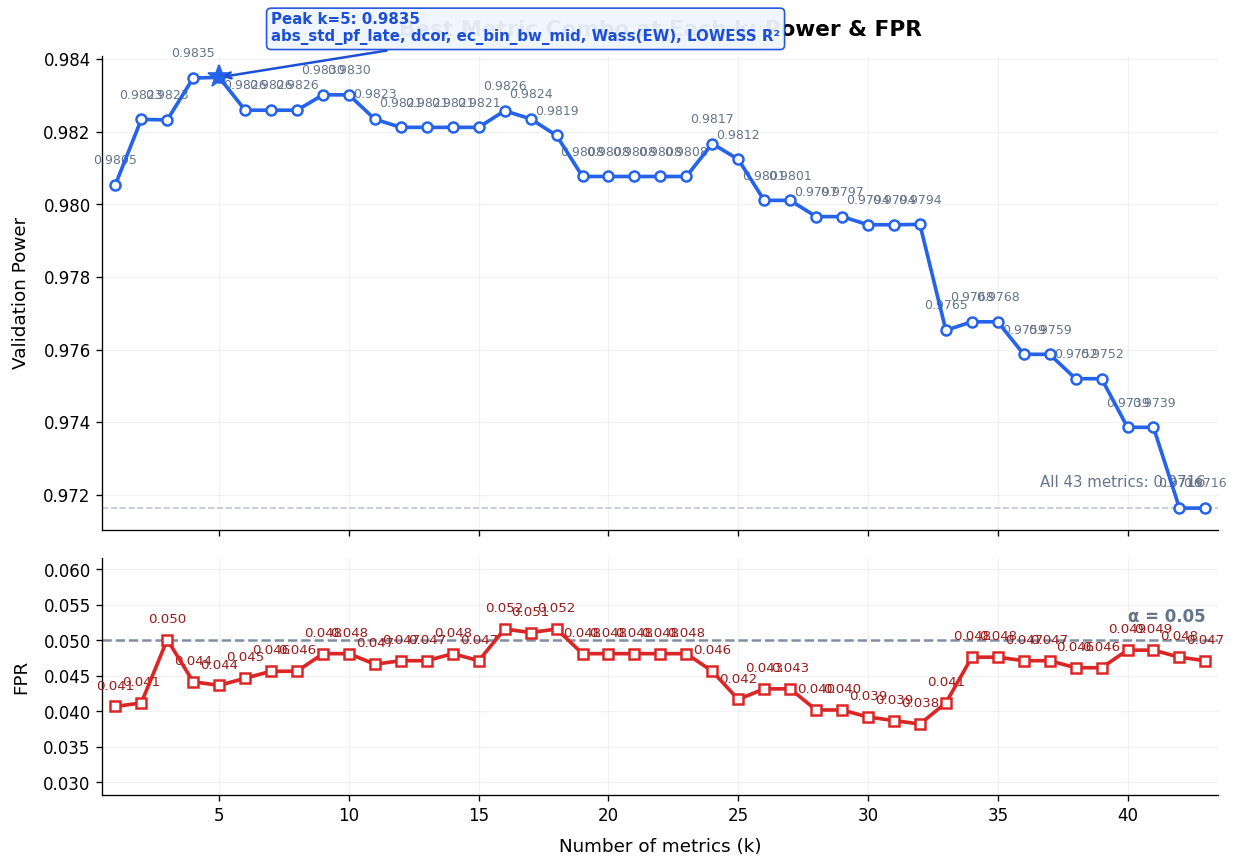

In [59]:
# Collect best combo per k across all search methods
all_by_k = pd.concat([
    exact_best,
    backward.assign(method='backward'),
    forward.assign(method='forward'),
    beam_best,
], ignore_index=True, sort=False)

best_per_k = (all_by_k
    .sort_values('train_macro_power', ascending=False)
    .drop_duplicates('k', keep='first')
    .sort_values('k'))

best_per_k.to_csv(OUT_DIR / 'best_per_k.csv', index=False, float_format='%.6f')

print('Best combo at each k:')
print(best_per_k[['k', 'method', 'display_metrics',
                   'validation_macro_power', 'validation_FPR']]
      .to_string(index=False, float_format='{:.4f}'.format))

# ── Dual panel: Power (top) + FPR (bottom) ──
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.08})

ks_plot = best_per_k['k'].values
powers_plot = best_per_k['validation_macro_power'].values
fprs_plot = best_per_k['validation_FPR'].values

# Top: Power
ax1.plot(ks_plot, powers_plot, '-o', color='#2563eb', markersize=6, lw=2.2, zorder=4,
         markerfacecolor='white', markeredgewidth=1.5)
ax1.axhline(FULL_POWER, color='#94a3b8', ls='--', lw=1, alpha=0.6)
ax1.text(ks_plot[-1], FULL_POWER + 0.0005,
         f'All {len(SAFE_METRICS)} metrics: {FULL_POWER:.4f}',
         fontsize=9, color='#64748b', ha='right', va='bottom')

peak_idx = best_per_k['train_macro_power'].idxmax()
pk = best_per_k.loc[peak_idx]
ax1.plot(pk['k'], pk['validation_macro_power'], '*', color='#2563eb',
         markersize=14, zorder=6)
ax1.annotate(f'Peak k={int(pk["k"])}: {pk["validation_macro_power"]:.4f}\n{pk["display_metrics"]}',
             xy=(pk['k'], pk['validation_macro_power']),
             xytext=(pk['k'] + 2, pk['validation_macro_power'] + 0.001),
             fontsize=9, color='#1d4ed8', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#1d4ed8', lw=1.5),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#eff6ff',
                       edgecolor='#1d4ed8', alpha=0.95), zorder=7)

for _, row in best_per_k.iterrows():
    k = int(row['k'])
    if k == int(pk['k']):
        continue
    ax1.text(k, row['validation_macro_power'] + 0.0005,
             f'{row["validation_macro_power"]:.4f}',
             fontsize=7.5, color='#64748b', ha='center', va='bottom')

ax1.set_ylabel(POWER_LABEL, fontsize=11, labelpad=8)
ax1.set_title('Best Metric Combo at Each k: Power & FPR',
              fontsize=13, fontweight='bold', pad=12)
ax1.grid(True, alpha=0.15)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(labelsize=10)

# Bottom: FPR
ax2.plot(ks_plot, fprs_plot, '-s', color='#dc2626', markersize=6, lw=2.2, zorder=4,
         markerfacecolor='white', markeredgewidth=1.5)
ax2.axhline(ALPHA, color='#64748b', ls='--', lw=1.5, alpha=0.8)
ax2.text(ks_plot[-1], ALPHA + 0.002, f'α = {ALPHA}',
         fontsize=10, color='#64748b', ha='right', va='bottom', fontweight='bold')

for _, row in best_per_k.iterrows():
    ax2.text(int(row['k']), row['validation_FPR'] + 0.002,
             f'{row["validation_FPR"]:.3f}',
             fontsize=8, color='#991b1b', ha='center', va='bottom')

ax2.set_xlabel('Number of metrics (k)', fontsize=11, labelpad=8)
ax2.set_ylabel('FPR', fontsize=11, labelpad=8)
ax2.set_xlim(0.5, ks_plot[-1] + 0.5)
fpr_range = max(fprs_plot.max() - fprs_plot.min(), 0.02)
ax2.set_ylim(max(0, fprs_plot.min() - fpr_range * 0.5),
             fprs_plot.max() + fpr_range * 0.5)
ax2.grid(True, alpha=0.15)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.tick_params(labelsize=10)

plt.tight_layout()
fig.savefig(OUT_DIR / 'best_per_k_power_fpr.png', dpi=200, bbox_inches='tight')
plt.show()

## §11 Visualization

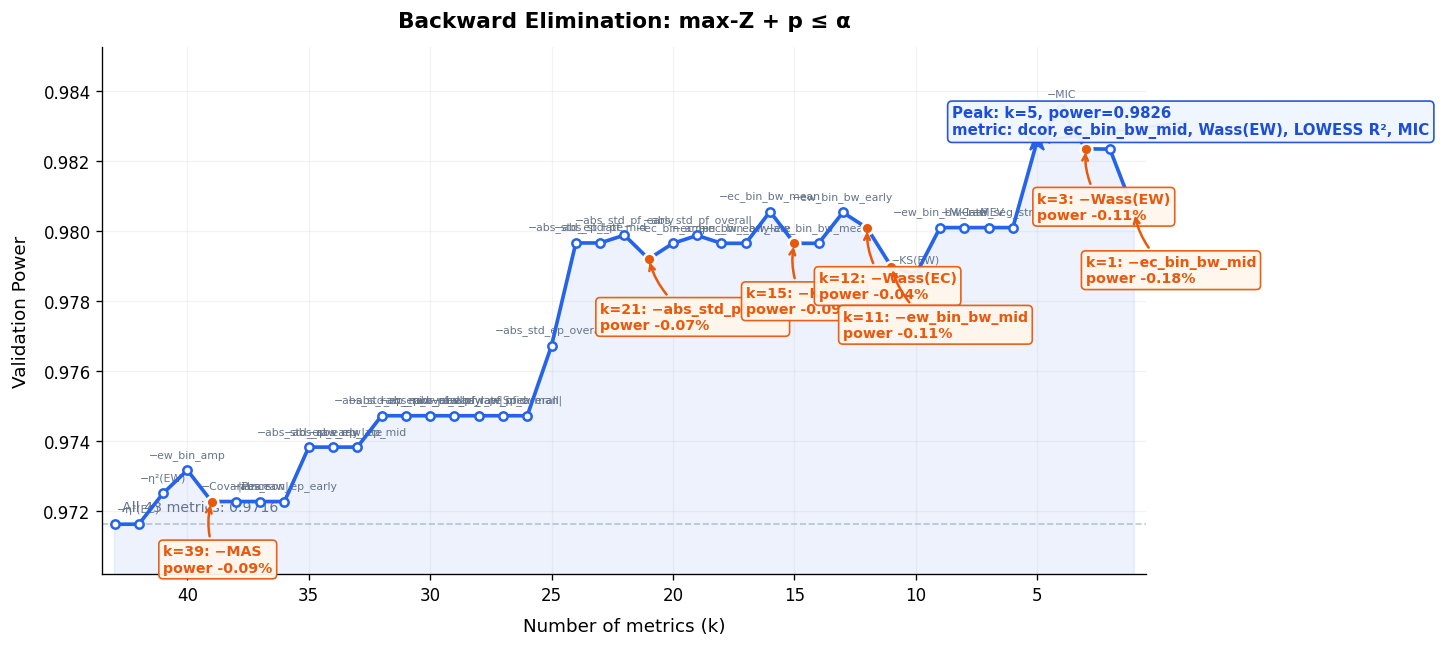

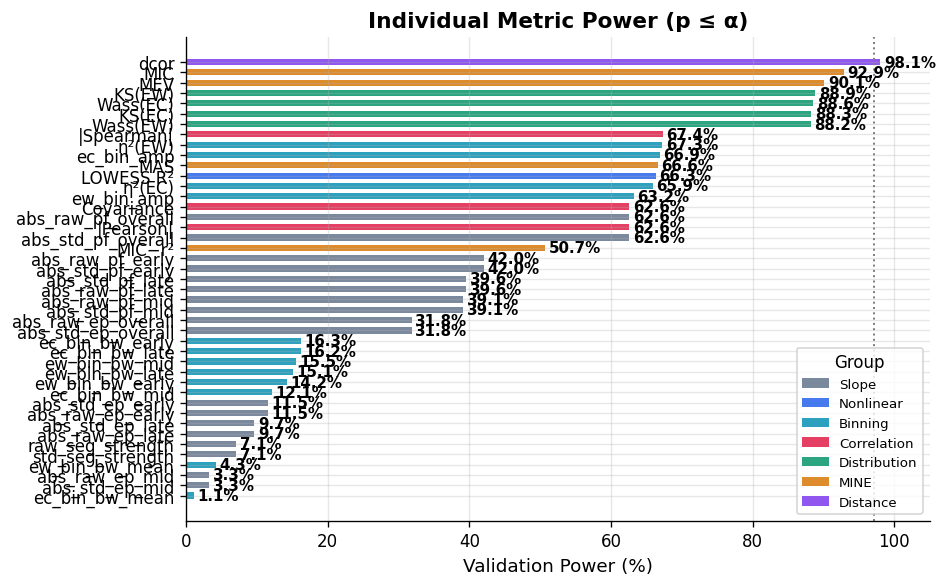

In [60]:
from matplotlib.patches import Patch

GROUP_COLORS = {
    'correlation': '#e11d48', 'distance': '#7c3aed', 'slope': '#64748b',
    'bin': '#0891b2', 'distribution': '#059669', 'mine': '#d97706', 'nonlinear': '#2563eb',
}
GROUP_LABELS = {
    'correlation': 'Correlation', 'distance': 'Distance', 'slope': 'Slope',
    'bin': 'Binning', 'distribution': 'Distribution', 'mine': 'MINE', 'nonlinear': 'Nonlinear',
}

# ═══════════════════════════════════════════════════
# Figure 1: Backward elimination
# ═══════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5.5))

bk = backward.copy()
ks = bk['k'].values
powers = bk['validation_macro_power'].values
k_max = int(ks[0])

ax.fill_between(ks, powers, alpha=0.08, color='#2563eb')
ax.plot(ks, powers, '-o', color='#2563eb', markersize=5, lw=2.2, zorder=4,
        markerfacecolor='white', markeredgewidth=1.5)

ax.axhline(FULL_POWER, color='#94a3b8', ls='--', lw=1, alpha=0.6)
ax.text(k_max - 0.3, FULL_POWER + 0.0003, f'All {k_max} metrics: {FULL_POWER:.4f}',
        fontsize=8.5, color='#64748b', ha='left', va='bottom')

peak_idx = bk['train_macro_power'].idxmax()
peak_row = bk.loc[peak_idx]
peak_k = int(peak_row['k'])
peak_power = peak_row['validation_macro_power']
peak_metrics = peak_row['display_metrics']

ax.plot(peak_k, peak_power, '*', color='#2563eb', markersize=14, zorder=6)
ax.annotate(
    f'Peak: k={peak_k}, power={peak_power:.4f}\nmetric: {peak_metrics}',
    xy=(peak_k, peak_power),
    xytext=(peak_k + 3.5, peak_power + 0.0002),
    fontsize=9, color='#1d4ed8', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#1d4ed8', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#eff6ff', edgecolor='#1d4ed8', alpha=0.95),
    zorder=7)

# Notable drops
drops = bk[bk['power_change'] < -0.0003]
for _, row in drops.iterrows():
    k = int(row['k'])
    removed = row['removed_display']
    power = row['validation_macro_power']
    change = row['power_change']
    ax.plot(k, power, 'o', color='#ea580c', markersize=7, zorder=6,
            markeredgecolor='white', markeredgewidth=1.5)
    ax.annotate(
        f'k={k}: −{removed}\npower {change:+.2%}',
        xy=(k, power), xytext=(k + 2, power - 0.002),
        fontsize=8.5, color='#ea580c', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='#ea580c', lw=1.5,
                        connectionstyle='arc3,rad=-0.2'),
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff7ed',
                  edgecolor='#ea580c', alpha=0.95),
        zorder=7)

for _, row in bk.iterrows():
    k = int(row['k'])
    removed = row['removed_display']
    if removed == '(start)' or k == peak_k or k in drops['k'].values:
        continue
    ax.text(k, row['validation_macro_power'] + 0.0003, f'−{removed}',
            fontsize=6.5, color='#64748b', ha='center', va='bottom')

ax.set_xlabel('Number of metrics (k)', fontsize=11, labelpad=8)
ax.set_ylabel(POWER_LABEL, fontsize=11, labelpad=8)
ax.set_title('Backward Elimination: max-Z + p ≤ α', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(k_max + 0.5, 0.5)
y_range = powers.max() - powers.min()
ax.set_ylim(powers.min() - y_range * 0.12, powers.max() + y_range * 0.15)
ax.grid(True, alpha=0.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=10)

plt.tight_layout()
fig.savefig(OUT_DIR / 'fig1_backward_elimination.png', dpi=200, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════
# Figure 2: Individual metric power
# ═══════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))
ind = individual.sort_values('validation_macro_power', ascending=True).copy()
names = ind['label'].values
powers_i = ind['validation_macro_power'].values * 100
colors = [GROUP_COLORS.get(g, '#999') for g in ind['group'].values]

ax.barh(range(len(names)), powers_i, color=colors, alpha=0.85, height=0.6)
for i, p in enumerate(powers_i):
    ax.text(p + 0.5, i, f'{p:.1f}%', va='center', fontsize=9, fontweight='bold')

ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=10)
ax.axvline(FULL_POWER * 100, color='gray', ls=':', lw=1.2)
ax.set_xlabel(f'{POWER_LABEL} (%)', fontsize=11)
ax.set_xlim(0, 105)
ax.set_title('Individual Metric Power (p ≤ α)', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

seen = []
handles = []
for g in ind['group'].values[::-1]:
    if g not in seen:
        seen.append(g)
        handles.append(Patch(facecolor=GROUP_COLORS.get(g, '#999'), label=GROUP_LABELS.get(g, g), alpha=0.85))
ax.legend(handles=handles[::-1], fontsize=8, loc='lower right', title='Group')

plt.tight_layout()
fig.savefig(OUT_DIR / 'fig2_individual_power.png', dpi=200, bbox_inches='tight')
plt.show()

## §12 Summary

In [61]:
print('=' * 70)
print('S3.2 Metric Ablation Summary')
print('=' * 70)
print(f'Method: T = max(Z), p = P(T_null ≥ T_obs), reject if p ≤ {ALPHA}')
print(f'Cases: {len(df):,} (MINE-covered)')
print(f'Metrics: {len(SAFE_METRICS)}')
print()

print(f'Baseline (all {len(SAFE_METRICS)} metrics):')
print(f'  Power = {FULL_POWER:.4f}, FPR = {baseline["validation_FPR"]:.4f}')
print()

peak = backward.loc[backward['train_macro_power'].idxmax()]
print(f'Backward elimination peak:')
print(f'  k = {int(peak["k"])}, metric = {peak["display_metrics"]}')
print(f'  Power = {peak["validation_macro_power"]:.4f}')
print(f'  Δ vs all: {peak["validation_macro_power"] - FULL_POWER:+.4f}')
print()

print('Removal order:')
for _, r in backward.iterrows():
    if r['removed_display'] == '(start)':
        continue
    ch = r['power_change']
    print(f'  k={int(r["k"]):2d}: −{r["removed_display"]:15s} → {r["validation_macro_power"]:.4f} ({ch:+.4f})')

S3.2 Metric Ablation Summary
Method: T = max(Z), p = P(T_null ≥ T_obs), reject if p ≤ 0.05
Cases: 9,008 (MINE-covered)
Metrics: 43

Baseline (all 43 metrics):
  Power = 0.9716, FPR = 0.0471

Backward elimination peak:
  k = 5, metric = dcor, ec_bin_bw_mid, Wass(EW), LOWESS R², MIC
  Power = 0.9826
  Δ vs all: +0.0109

Removal order:
  k=42: −η²(EC)          → 0.9716 (+0.0000)
  k=41: −η²(EW)          → 0.9725 (+0.0009)
  k=40: −ew_bin_amp      → 0.9732 (+0.0007)
  k=39: −MAS             → 0.9723 (-0.0009)
  k=38: −Covariance      → 0.9723 (+0.0000)
  k=37: −|Pearson|       → 0.9723 (+0.0000)
  k=36: −abs_raw_ep_early → 0.9723 (+0.0000)
  k=35: −abs_std_ep_early → 0.9738 (+0.0016)
  k=34: −abs_raw_ep_late → 0.9738 (+0.0000)
  k=33: −abs_raw_ep_mid  → 0.9738 (+0.0000)
  k=32: −abs_std_ep_mid  → 0.9747 (+0.0009)
  k=31: −abs_raw_ep_overall → 0.9747 (+0.0000)
  k=30: −abs_raw_pf_early → 0.9747 (+0.0000)
  k=29: −abs_raw_pf_late → 0.9747 (+0.0000)
  k=28: −abs_raw_pf_mid  → 0.9747 (+0.0000)